<a href="https://colab.research.google.com/github/ankitkumar2023/Part-2-RFM-Segmentation-Retention-Strategy/blob/main/rfm_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Google Drive Setup, Imports, Dataset Loading, and Data Preparation

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configure notebook display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Configure visualization style
plt.style.use("default")
sns.set_style("whitegrid")

# Step 2: Mount Google Drive and establish the project directory containing all D2C customer datasets.

In [2]:


from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import os

BASE_PATH = "/content/drive/MyDrive/d2c churn data package/"

try:
    files = os.listdir(BASE_PATH)
    print("Success! Colab sees the folder. Here are the files inside:")
    for file in files:
        print(f"- {file}")
except FileNotFoundError:
    print("Error: Colab STILL cannot find the folder. The sync might need another minute.")

Success! Colab sees the folder. Here are the files inside:
- web_events_snapshot.csv
- churn_labels.csv
- rfm_modeling_snapshot.csv
- support_tickets.csv
- customers.csv
- orders.csv
- intervention_history.csv
- STUDENT_FACING_PROBLEM_STATEMENT.md
- DATA_DICTIONARY.md


# Step 3: Load all raw datasets required for RFM segmentation and behavioral customer analysis.

In [8]:
customers = pd.read_csv(
    BASE_PATH + "customers.csv"
)

orders = pd.read_csv(
    BASE_PATH + "orders.csv",
    parse_dates=["order_date"]
)

support_tickets = pd.read_csv(
    BASE_PATH + "support_tickets.csv",
    parse_dates=["ticket_date"]
)

web_events = pd.read_csv(
    BASE_PATH + "web_events_snapshot.csv",
    parse_dates=["snapshot_date"]
)

intervention_history = pd.read_csv(
    BASE_PATH + "intervention_history.csv",
    parse_dates=["snapshot_date"]
)

# Step 4: Validate successful dataset loading by checking dimensions and displaying sample observations.

In [9]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Support Tickets": support_tickets,
    "Web Events": web_events,
    "Intervention History": intervention_history
}

for name, dataframe in datasets.items():
    print("=" * 70)
    print(f"{name} Dataset Shape: {dataframe.shape}")
    print("=" * 70)
    display(dataframe.head(3))

Customers Dataset Shape: (2400, 9)


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes


Orders Dataset Shape: (10009, 10)


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0


Support Tickets Dataset Shape: (1921, 8)


,ticket_id,customer_id,ticket_date,issue_type,support_channel,resolution_hours,sentiment_score,reopened
0,TKT000001,CUST00001,2024-10-28,damaged_item,chat,3.9,-0.16,0
1,TKT000002,CUST00001,2025-02-03,payment_issue,chat,4.8,0.44,0
2,TKT000003,CUST00002,2025-08-30,late_delivery,chat,1.0,0.00,0


Web Events Dataset Shape: (2400, 10)


,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26


Intervention History Dataset Shape: (2400, 5)


,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,18,high


# Step 5: Define snapshot date and remove future transactions to prevent target leakage issues.

In [6]:
SNAPSHOT_DATE = pd.Timestamp("2025-09-30")

orders_filtered = orders[
    orders["order_date"] <= SNAPSHOT_DATE
].copy()

print("Original Orders:", len(orders))
print("Pre-snapshot Orders Used:", len(orders_filtered))

Original Orders: 10009
Pre-snapshot Orders Used: 8137


# Step 6: Remove Duplicate-Like Order Records

This step eliminates simulated duplicate transactions to maintain accurate purchase frequency calculations.

In [10]:
duplicate_records = orders[
    orders["order_id"].str.contains("_DUP")
]

print("Duplicate-Like Records Found:")
print(duplicate_records.shape[0])

orders = orders[
    ~orders["order_id"].str.contains("_DUP")
].copy()

print("Orders Remaining After Cleaning:")
print(orders.shape[0])

Duplicate-Like Records Found:
12
Orders Remaining After Cleaning:
9997


# Step 7: Analyze Missing Values Across All Datasets
This step identifies incomplete information requiring awareness before building customer segmentation features.

In [11]:
datasets["Orders"] = orders

for name, dataframe in datasets.items():
    print("\n" + "=" * 70)
    print(f"Missing Value Summary: {name}")
    print("=" * 70)
    print(dataframe.isnull().sum())


Missing Value Summary: Customers
customer_id               0
signup_date               0
city_tier                 0
age_group                 0
acquisition_channel       0
loyalty_tier           1386
preferred_category        0
skin_type               401
marketing_consent         0
dtype: int64

Missing Value Summary: Orders
order_id          0
customer_id       0
order_date        0
category          0
quantity          0
gross_amount      0
discount_pct      0
delivery_days     0
returned          0
rating           80
dtype: int64

Missing Value Summary: Support Tickets
ticket_id           0
customer_id         0
ticket_date         0
issue_type          0
support_channel     0
resolution_hours    0
sentiment_score     0
reopened            0
dtype: int64

Missing Value Summary: Web Events
customer_id            0
snapshot_date          0
sessions_30d           0
product_views_30d      0
cart_adds_30d          0
wishlist_adds_30d      0
abandoned_carts_30d    0
email_opens_30d   

# Step 8: Calculate Actual Customer Spending After Discounts
This step computes realistic monetary values because discounts affect true customer revenue contribution.

In [12]:
orders["net_amount"] = (
    orders["gross_amount"] *
    (1 - orders["discount_pct"])
)

print("Net Revenue Calculation Sample")

display(
    orders[
        [
            "customer_id",
            "gross_amount",
            "discount_pct",
            "net_amount"
        ]
    ].head()
)

Net Revenue Calculation Sample


,customer_id,gross_amount,discount_pct,net_amount
0,CUST00001,540.70,0.43,308.1990
1,CUST00001,467.96,0.64,168.4656
2,CUST00001,581.81,0.27,424.7213
3,CUST00001,433.15,0.27,316.1995
4,CUST00001,569.22,0.34,375.6852


# Step 9: Validate Cleaned Transaction Dataset

This step confirms cleaned purchase history before generating customer-level RFM behavioral indicators.

In [13]:
print("=" * 70)
print("CLEAN TRANSACTION SUMMARY")
print("=" * 70)

print(
    "Total Transactions:",
    orders.shape[0]
)

print(
    "Unique Customers:",
    orders["customer_id"].nunique()
)

print(
    "First Purchase Date:",
    orders["order_date"].min()
)

print(
    "Last Purchase Date:",
    orders["order_date"].max()
)

CLEAN TRANSACTION SUMMARY
Total Transactions: 9997
Unique Customers: 2400
First Purchase Date: 2024-01-09 00:00:00
Last Purchase Date: 2025-11-29 00:00:00


# Step 10: Create a Complete Customer Master Table

This step preserves all registered customers including individuals without any purchase history.

In [14]:
customer_master = customers[
    ["customer_id"]
].copy()

print(
    "Total Customers Available for Segmentation:",
    customer_master.shape[0]
)

display(customer_master.head())

Total Customers Available for Segmentation: 2400


,customer_id
0,CUST00001
1,CUST00002
2,CUST00003
3,CUST00004
4,CUST00005


# Step 11: Prepare Transaction Dataset for RFM Calculations

This step organizes cleaned order information required for recency, frequency, and monetary calculations.

In [15]:
rfm_orders = orders[
    [
        "customer_id",
        "order_date",
        "order_id",
        "net_amount",
        "returned",
        "discount_pct"
    ]
].copy()

print("RFM Transaction Dataset Shape:")
print(rfm_orders.shape)

display(rfm_orders.head())

RFM Transaction Dataset Shape:
(9997, 6)


,customer_id,order_date,order_id,net_amount,returned,discount_pct
0,CUST00001,2024-08-06,ORD000001,308.1990,0,0.43
1,CUST00001,2024-10-23,ORD000002,168.4656,1,0.64
2,CUST00001,2025-01-18,ORD000006,424.7213,0,0.27
3,CUST00001,2025-01-22,ORD000005,316.1995,0,0.27
4,CUST00001,2025-02-28,ORD000004,375.6852,0,0.34


# Step 12: Calculate Customer Recency Feature
This step measures recent customer activity because recent buyers usually demonstrate stronger brand engagement.

In [16]:
recency = (
    rfm_orders
    .groupby("customer_id")
    ["order_date"]
    .max()
    .reset_index()
)

recency["recency_days"] = (
    SNAPSHOT_DATE - recency["order_date"]
).dt.days

recency = recency[
    [
        "customer_id",
        "recency_days"
    ]
]

display(recency.head())

,customer_id,recency_days
0,CUST00001,107
1,CUST00002,-26
2,CUST00003,171
3,CUST00004,131
4,CUST00005,-50


# Step 13: Calculate Customer Frequency Feature
This step counts customer purchases because repeated transactions indicate loyalty and purchasing consistency.

In [17]:
frequency = (
    rfm_orders
    .groupby("customer_id")
    ["order_id"]
    .count()
    .reset_index()
)

frequency.rename(
    columns={
        "order_id": "frequency"
    },
    inplace=True
)

display(frequency.head())

,customer_id,frequency
0,CUST00001,6
1,CUST00002,3
2,CUST00003,1
3,CUST00004,1
4,CUST00005,6


# Step 14: Calculate Customer Monetary Feature
This step determines customer revenue contribution because spending amount reflects overall commercial importance.

In [18]:
monetary = (
    rfm_orders
    .groupby("customer_id")
    ["net_amount"]
    .sum()
    .reset_index()
)

monetary.rename(
    columns={
        "net_amount": "monetary_value"
    },
    inplace=True
)

display(monetary.head())

,customer_id,monetary_value
0,CUST00001,1872.5727
1,CUST00002,1386.9362
2,CUST00003,344.4894
3,CUST00004,1347.3936
4,CUST00005,2463.7209


# Step 15: Combine Recency, Frequency, and Monetary Features
This step creates a unified customer value table combining essential RFM behavioral measurements.

In [19]:
rfm = (
    customer_master
    .merge(
        recency,
        on="customer_id",
        how="left"
    )
    .merge(
        frequency,
        on="customer_id",
        how="left"
    )
    .merge(
        monetary,
        on="customer_id",
        how="left"
    )
)

rfm["recency_days"] = (
    rfm["recency_days"]
    .fillna(999)
)

rfm["frequency"] = (
    rfm["frequency"]
    .fillna(0)
)

rfm["monetary_value"] = (
    rfm["monetary_value"]
    .fillna(0)
)

display(rfm.head())

,customer_id,recency_days,frequency,monetary_value
0,CUST00001,107,6,1872.5727
1,CUST00002,-26,3,1386.9362
2,CUST00003,171,1,344.4894
3,CUST00004,131,1,1347.3936
4,CUST00005,-50,6,2463.7209


# Step 16: Calculate Customer Return Rate as Non-RFM Behavioral Signal
This step evaluates product dissatisfaction because excessive returns may indicate elevated churn probability.

In [20]:
returns = (
    rfm_orders
    .groupby("customer_id")
    ["returned"]
    .mean()
    .reset_index()
)

returns.rename(
    columns={
        "returned": "return_rate"
    },
    inplace=True
)

returns["return_rate"] = (
    returns["return_rate"]
    .fillna(0)
)

display(returns.head())

,customer_id,return_rate
0,CUST00001,0.166667
1,CUST00002,0.000000
2,CUST00003,0.000000
3,CUST00004,0.000000
4,CUST00005,0.000000


# Step 17: Calculate Support Complaint Count as Customer Experience Signal
This step captures service friction because unresolved problems negatively influence customer retention likelihood.

In [21]:
support_features = (
    support_tickets
    .groupby("customer_id")
    ["ticket_id"]
    .count()
    .reset_index()
)

support_features.rename(
    columns={
        "ticket_id": "support_ticket_count"
    },
    inplace=True
)

display(support_features.head())

,customer_id,support_ticket_count
0,CUST00001,2
1,CUST00002,1
2,CUST00005,1
3,CUST00006,2
4,CUST00008,1


# Step 18: Calculate Web Engagement Metrics for Digital Activity Understanding
This step incorporates online behavior because engagement levels reveal customer interest before purchasing.

In [22]:
web_features = web_events[
    [
        "customer_id",
        "sessions_30d",
        "product_views_30d",
        "campaign_clicks_30d"
    ]
].copy()

display(web_features.head())

,customer_id,sessions_30d,product_views_30d,campaign_clicks_30d
0,CUST00001,1,4,0
1,CUST00002,8,31,0
2,CUST00003,1,3,0
3,CUST00004,1,6,0
4,CUST00005,18,95,1


# Step 19: Calculate Average Discount Usage Dependency
This step identifies discount reliance because price-sensitive customers require different retention strategies.

In [23]:
discount_features = (
    rfm_orders
    .groupby("customer_id")
    ["discount_pct"]
    .mean()
    .reset_index()
)

discount_features.rename(
    columns={
        "discount_pct": "average_discount_used"
    },
    inplace=True
)

display(discount_features.head())

,customer_id,average_discount_used
0,CUST00001,0.363333
1,CUST00002,0.190000
2,CUST00003,0.470000
3,CUST00004,0.160000
4,CUST00005,0.388333


# Step 20: Merge RFM and Additional Behavioral Features
This step builds a complete customer profile enabling advanced business-driven segmentation decisions.

In [24]:
customer_features = (
    rfm
    .merge(
        returns,
        on="customer_id",
        how="left"
    )
    .merge(
        support_features,
        on="customer_id",
        how="left"
    )
    .merge(
        web_features,
        on="customer_id",
        how="left"
    )
    .merge(
        discount_features,
        on="customer_id",
        how="left"
    )
)

numeric_columns = [
    "return_rate",
    "support_ticket_count",
    "sessions_30d",
    "product_views_30d",
    "campaign_clicks_30d",
    "average_discount_used"
]

customer_features[numeric_columns] = (
    customer_features[numeric_columns]
    .fillna(0)
)

print(
    "Final Customer Feature Table Shape:"
)

print(customer_features.shape)

display(customer_features.head())

Final Customer Feature Table Shape:
(2400, 10)


,customer_id,recency_days,frequency,monetary_value,return_rate,support_ticket_count,sessions_30d,product_views_30d,campaign_clicks_30d,average_discount_used
0,CUST00001,107,6,1872.5727,0.166667,2.0,1,4,0,0.363333
1,CUST00002,-26,3,1386.9362,0.000000,1.0,8,31,0,0.190000
2,CUST00003,171,1,344.4894,0.000000,0.0,1,3,0,0.470000
3,CUST00004,131,1,1347.3936,0.000000,0.0,1,6,0,0.160000
4,CUST00005,-50,6,2463.7209,0.000000,1.0,18,95,1,0.388333


# Step 21: Generate Summary Statistics for Segmentation Threshold Selection
This step analyzes customer distributions helping define realistic and data-driven segmentation boundaries.

In [25]:
summary_statistics = (
    customer_features.describe()
)

display(summary_statistics)

,recency_days,frequency,monetary_value,return_rate,support_ticket_count,sessions_30d,product_views_30d,campaign_clicks_30d,average_discount_used
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,45.552083,4.165417,2316.450466,0.072871,0.800417,5.460000,23.021667,0.649583,0.275101
std,103.035447,2.622038,1798.544435,0.172520,0.976890,4.400167,19.818043,0.951579,0.086383
min,-60.000000,1.000000,63.012600,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-38.000000,2.000000,992.891250,0.000000,0.000000,2.000000,7.000000,0.000000,0.216667
50%,-5.000000,4.000000,1912.872900,0.000000,1.000000,5.000000,18.000000,0.000000,0.273030
75%,119.250000,6.000000,3194.931925,0.000000,1.000000,8.000000,34.000000,1.000000,0.330000
max,562.000000,17.000000,22512.796300,1.000000,6.000000,25.000000,119.000000,6.000000,0.620000


# Step 22: Define Business Rules for Exactly Five Customer Segments
This step applies RFM and behavioral thresholds to classify customers into meaningful retention groups.

In [26]:
def assign_customer_segment(row):

    # Segment 1: Champions
    if (
        row["recency_days"] <= 30
        and row["frequency"] >= 5
        and row["monetary_value"] >= 5000
        and row["return_rate"] < 0.20
        and row["support_ticket_count"] <= 1
    ):
        return "Champions"

    # Segment 2: Loyal Customers
    elif (
        row["recency_days"] <= 90
        and row["frequency"] >= 3
        and row["monetary_value"] >= 2000
        and row["support_ticket_count"] <= 3
    ):
        return "Loyal Customers"

    # Segment 3: High Value but Unhappy
    elif (
        row["monetary_value"] >= 3000
        and (
            row["support_ticket_count"] >= 3
            or row["return_rate"] >= 0.30
        )
    ):
        return "High Value but Unhappy"

    # Segment 4: Discount Sensitive
    elif (
        row["average_discount_used"] >= 0.30
        and row["frequency"] >= 2
    ):
        return "Discount Sensitive"

    # Segment 5: Dormant and At Risk
    else:
        return "Dormant and At Risk"

# Step 23: Apply Segmentation Rules Across Complete Customer Population
This step assigns every customer a single segment using established behavioral decision rules.

In [27]:
customer_features["segment_name"] = (
    customer_features.apply(
        assign_customer_segment,
        axis=1
    )
)

display(
    customer_features[
        [
            "customer_id",
            "segment_name"
        ]
    ].head(10)
)

,customer_id,segment_name
0,CUST00001,Discount Sensitive
1,CUST00002,Dormant and At Risk
2,CUST00003,Dormant and At Risk
3,CUST00004,Dormant and At Risk
4,CUST00005,Loyal Customers
5,CUST00006,Loyal Customers
6,CUST00007,Dormant and At Risk
7,CUST00008,Loyal Customers
8,CUST00009,Discount Sensitive
9,CUST00010,Discount Sensitive


# Step 24: Analyze Segment Distribution Across Customer Base
This step evaluates customer proportions because retention resources must target important groups strategically.

In [28]:
segment_distribution = (
    customer_features["segment_name"]
    .value_counts()
    .reset_index()
)

segment_distribution.columns = [
    "segment_name",
    "customer_count"
]

display(segment_distribution)

,segment_name,customer_count
0,Dormant and At Risk,991
1,Loyal Customers,765
2,Discount Sensitive,514
3,Champions,77
4,High Value but Unhappy,53


# Step 25: Visualize Customer Segment Population
This step creates graphical insights allowing business teams to understand segment size differences.

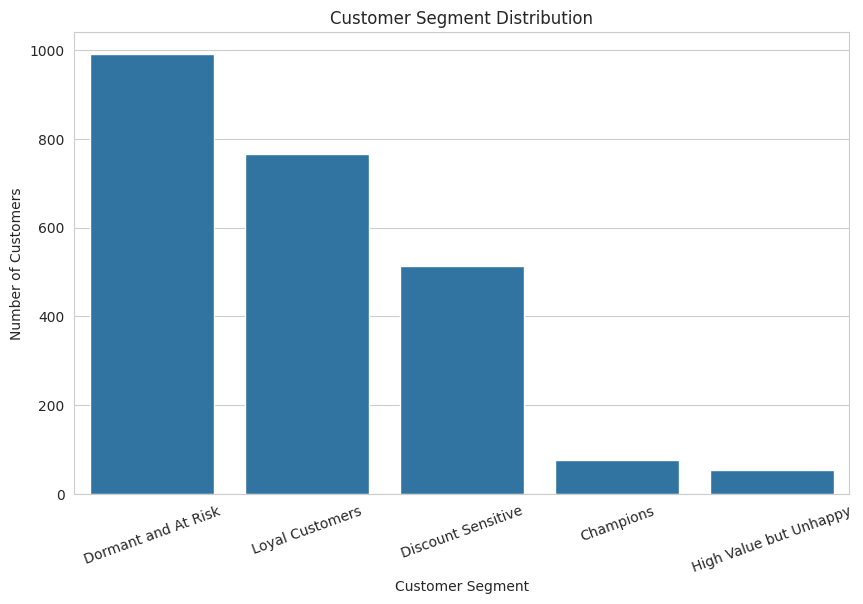

In [29]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=segment_distribution,
    x="segment_name",
    y="customer_count"
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

# Step 26: Compare Average RFM Metrics Across Customer Segments
This step validates segmentation effectiveness by comparing purchasing behavior patterns among different customer groups.

In [31]:
rfm_comparison = (
    customer_features
    .groupby("segment_name")[
        [
            "recency_days",
            "frequency",
            "monetary_value"
        ]
    ]
    .mean()
    .round(2)
)

display(rfm_comparison)

,recency_days,frequency,monetary_value
segment_name,,,
Champions,-31.78,8.52,6250.46
Discount Sensitive,71.46,3.45,1419.67
Dormant and At Risk,91.69,2.46,1399.01
High Value but Unhappy,31.11,8.96,4965.34
Loyal Customers,-22.83,6.09,3527.98


# Step 27: Visualize Average Monetary Contribution by Customer Segment
This step highlights revenue contribution differences helping prioritize valuable customer retention opportunities.

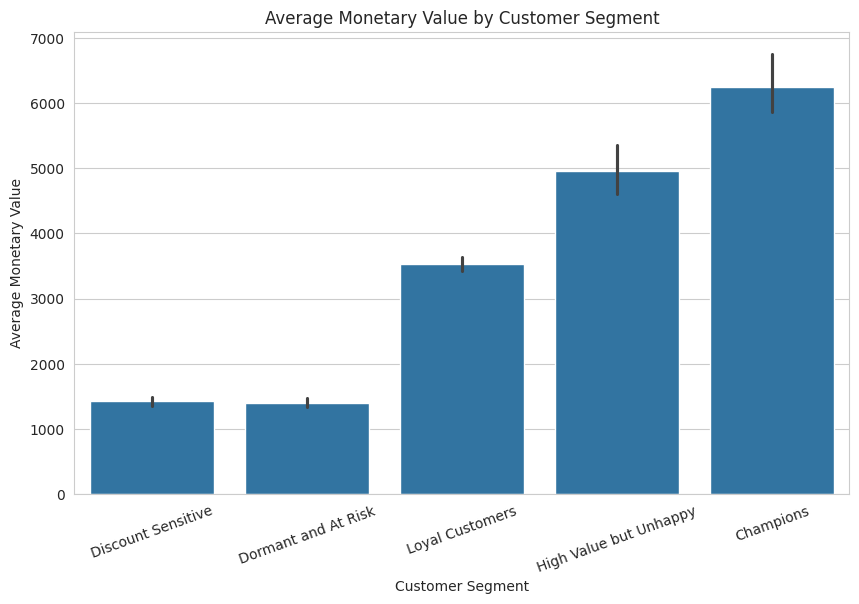

In [32]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=customer_features,
    x="segment_name",
    y="monetary_value",
    estimator=np.mean
)

plt.title("Average Monetary Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Monetary Value")
plt.xticks(rotation=20)

plt.show()

# Step 28: Analyze Non-RFM Behavioral Metrics Across Customer Segments
This step examines support issues, returns, and engagement patterns validating behavioral segmentation decisions.

In [33]:
behavior_summary = (
    customer_features
    .groupby("segment_name")[
        [
            "support_ticket_count",
            "return_rate",
            "sessions_30d",
            "average_discount_used"
        ]
    ]
    .mean()
    .round(2)
)

display(behavior_summary)

,support_ticket_count,return_rate,sessions_30d,average_discount_used
segment_name,,,,
Champions,0.56,0.03,6.61,0.24
Discount Sensitive,0.68,0.06,4.90,0.36
Dormant and At Risk,0.48,0.08,4.76,0.25
High Value but Unhappy,3.91,0.14,6.38,0.28
Loyal Customers,1.10,0.07,6.56,0.26


# Step 29: Visualize Customer Support Complaints Across Segments
This step identifies customer experience problems requiring immediate service recovery interventions.

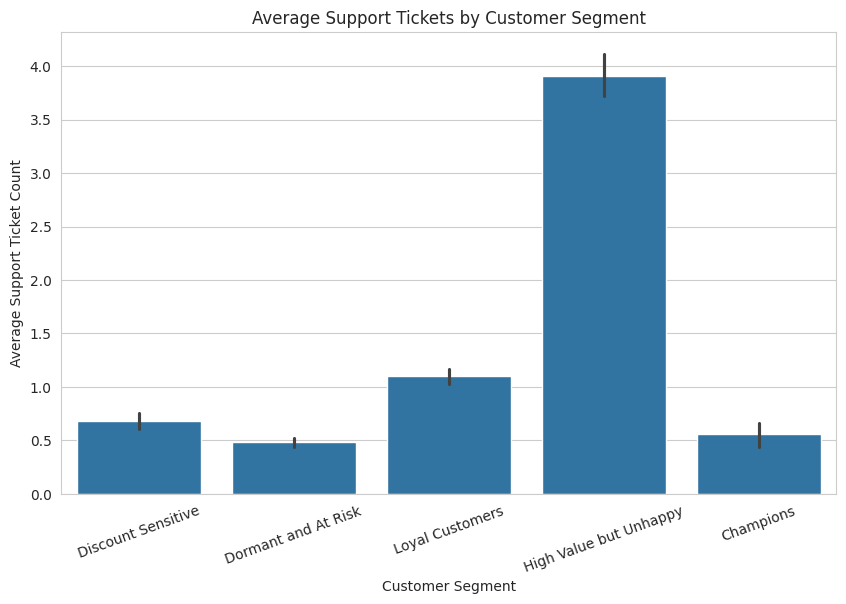

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=customer_features,
    x="segment_name",
    y="support_ticket_count",
    estimator=np.mean
)

plt.title("Average Support Tickets by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Support Ticket Count")
plt.xticks(rotation=20)

plt.show()

# Step 30: Create Final Segmentation Output Dataset
This step selects important customer attributes required for business actions and repository submission.

In [35]:
segments = customer_features[
    [
        "customer_id",
        "segment_name",
        "recency_days",
        "frequency",
        "monetary_value",
        "return_rate",
        "support_ticket_count",
        "sessions_30d",
        "product_views_30d",
        "campaign_clicks_30d",
        "average_discount_used"
    ]
].copy()

display(segments.head())

,customer_id,segment_name,recency_days,frequency,monetary_value,return_rate,support_ticket_count,sessions_30d,product_views_30d,campaign_clicks_30d,average_discount_used
0,CUST00001,Discount Sensitive,107,6,1872.5727,0.166667,2.0,1,4,0,0.363333
1,CUST00002,Dormant and At Risk,-26,3,1386.9362,0.000000,1.0,8,31,0,0.190000
2,CUST00003,Dormant and At Risk,171,1,344.4894,0.000000,0.0,1,3,0,0.470000
3,CUST00004,Dormant and At Risk,131,1,1347.3936,0.000000,0.0,1,6,0,0.160000
4,CUST00005,Loyal Customers,-50,6,2463.7209,0.000000,1.0,18,95,1,0.388333


# Step 31: Save Segmentation Results as Required CSV File
This step exports final customer segments enabling CRM teams and evaluators to access results.

In [36]:
segments.to_csv(
    "segments.csv",
    index=False
)

print("segments.csv successfully generated")
print("Total customer records:", segments.shape[0])

segments.csv successfully generated
Total customer records: 2400


# Step 32: Generate Segment-Level Business Summary Table
This step summarizes customer groups providing evidence supporting retention strategy recommendations.

In [37]:
segment_summary = (
    segments
    .groupby("segment_name")
    .agg({
        "customer_id": "count",
        "monetary_value": "mean",
        "frequency": "mean",
        "recency_days": "mean",
        "return_rate": "mean",
        "support_ticket_count": "mean"
    })
    .round(2)
)

segment_summary.rename(
    columns={
        "customer_id": "customer_count"
    },
    inplace=True
)

display(segment_summary)

,customer_count,monetary_value,frequency,recency_days,return_rate,support_ticket_count
segment_name,,,,,,
Champions,77,6250.46,8.52,-31.78,0.03,0.56
Discount Sensitive,514,1419.67,3.45,71.46,0.06,0.68
Dormant and At Risk,991,1399.01,2.46,91.69,0.08,0.48
High Value but Unhappy,53,4965.34,8.96,31.11,0.14,3.91
Loyal Customers,765,3527.98,6.09,-22.83,0.07,1.10


# Step 33: Identify Top Revenue Generating Customers for Manual Review
This step helps discover important customers requiring personalized retention decisions.

In [38]:
high_value_customers = (
    segments
    .sort_values(
        by="monetary_value",
        ascending=False
    )
    .head(10)
)

display(high_value_customers)

,customer_id,segment_name,recency_days,frequency,monetary_value,return_rate,support_ticket_count,sessions_30d,product_views_30d,campaign_clicks_30d,average_discount_used
1867,CUST01868,Loyal Customers,80,3,22512.7963,0.000000,0.0,4,18,1,0.216667
210,CUST00211,Champions,-33,7,20415.1379,0.000000,1.0,4,20,0,0.317143
2105,CUST02106,Loyal Customers,-29,9,15184.5426,0.111111,3.0,7,26,1,0.295556
1987,CUST01988,Loyal Customers,-58,4,13235.1724,0.000000,0.0,2,6,0,0.130000
1294,CUST01295,Dormant and At Risk,121,4,11636.5880,0.250000,1.0,11,53,0,0.155000
271,CUST00272,Champions,-7,14,11046.7770,0.000000,0.0,7,42,0,0.231429
2153,CUST02154,Loyal Customers,-11,17,10378.3165,0.058824,3.0,10,32,2,0.186471
990,CUST00991,Loyal Customers,-12,12,9235.6074,0.000000,2.0,9,41,1,0.226667
799,CUST00800,High Value but Unhappy,-6,11,9219.0908,0.181818,4.0,7,20,2,0.175455
816,CUST00817,Champions,-18,15,9009.6478,0.000000,1.0,13,55,2,0.309333


# Step 34: Verify Final Project Deliverables and Segmentation Completion
This step confirms generated outputs satisfy repository requirements and evaluation expectations.

In [39]:
print("=" * 70)
print("RFM SEGMENTATION PROJECT COMPLETED")
print("=" * 70)

print("Generated Deliverables:")
print("1. Customer segmentation dataframe")
print("2. Segment analytical tables")
print("3. Customer behavior visualizations")
print("4. segments.csv export")

print("\nFinal Segment Counts:")
print(
    segments["segment_name"].value_counts()
)

RFM SEGMENTATION PROJECT COMPLETED
Generated Deliverables:
1. Customer segmentation dataframe
2. Segment analytical tables
3. Customer behavior visualizations
4. segments.csv export

Final Segment Counts:
segment_name
Dormant and At Risk       991
Loyal Customers           765
Discount Sensitive        514
Champions                  77
High Value but Unhappy     53
Name: count, dtype: int64
